# Polarized Trees — Exploring the benchmark results

Third notebook of the synthetic workflow:

1. `datasetdemo.ipynb` — generate the fixed synthetic corpora;
2. `treesbenchmark.ipynb` — search the hyperparameters and save the results;
3. **this notebook** — explore the saved results: what the search found and which settings matter;
4. `pegcomparison.ipynb` — take settings from the top 20, keep everything fixed except the PEG formulation, and compare the formulations.

Nothing here changes the selected configuration. It reads what the benchmark saved (`benchmark_results/`) and answers questions about it:

1. **The search**: how many configurations, and how good are they?
2. **The top 20**: settings, every metric, and the same per corpus (A, B, C, overall).
3. **Formulations**: which PEG formulations are in the top 20?
4. **Hyperparameters**: how much does each one matter?
5. **`relative_h`**: a closer look, with a controlled experiment.
6. **Corpora**: do the same settings work on A, B and C?
7. **By k**: recovery by the true number of active dimensions of a text.

More questions can be added as sections: each one starts from the tables loaded in section 1.

> Run `datasetdemo.ipynb` and `treesbenchmark.ipynb` first, so that `benchmark_data/` and `benchmark_results/` exist.

## 1. Setup

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Locate the benchmarks folder (it holds benchmark_config.py).
CWD = Path.cwd().resolve()

if (CWD / "benchmark_config.py").exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / "benchmark_config.py").exists():
    PROJECT_ROOT = CWD.parent
else:
    raise FileNotFoundError(
        "Could not locate project root. "
        "Run this notebook from the notebooks directory "
        "or the project root."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


from benchmark_config import (
    DIMS,
    RESULTS_DIR,
    SCALE,
    check_polartox,
    load_benchmark_corpora,
    load_benchmark_dataset,
)

check_polartox()    # which polartox and which library versions produce these results

from polartox import PolarizedTreesBenchmark, PolarizedTreesPipeline
from polartox.polarized_tree import PEG_VARIANTS

# Everything this notebook saves goes here, never over the benchmark notebook's results.
OUT_DIR = RESULTS_DIR / "exploration"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# What the benchmark saved.
report = json.loads((RESULTS_DIR / "benchmark_report.json").read_text(encoding="utf-8"))
summary = pd.read_csv(RESULTS_DIR / "benchmark_configuration_summary.csv")     # one row per configuration (A, B, C averaged)
by_corpus = pd.read_csv(RESULTS_DIR / "benchmark_results.csv")                 # one row per configuration and corpus
top = pd.read_csv(RESULTS_DIR / "top_configurations.csv")                      # the top 20

SETTINGS = ["theta_filter", "min_size_frac", "max_depth", "h", "relative_h", "theta_stop"]
METRICS = ["jaccard", "precision", "recall", "exact_match"]
STAT_NAMES = ["median", "std", "q1", "q3", "min", "max"]      # the distribution of a metric over the texts
CORPORA = list(by_corpus["corpus"].unique())

# Chart style: ink and grid colours, and categorical slots 1 and 2 (the markers differ as well, so colour is not the only cue).
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e6e5e1"
BLUE, ORANGE = "#2a78d6", "#eb6834"


def style_axes(ax):
    ax.set_facecolor("white")
    ax.grid(axis="y", color=GRID, linewidth=1)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(MUTED)
    ax.tick_params(colors=MUTED, labelsize=9)

polartox 0.8.0 imported from C:\Users\swkra\OneDrive\Υπολογιστής\ερευνα\HumanModelAlign\polarizedtrees\polartox\__init__.py
PEG formulations: ('max', 'avg', 'min', 'mean', 'harmonic')
numpy 2.5.3
pandas 3.0.6
ndfu 0.9.3
scikit-learn 1.9.1


## 2. The search

How many configurations were evaluated, what the search space was, and how the mean Jaccard (over A, B and C) is distributed over all of them.

In [2]:
search = report["benchmark"]
print(f"{search['total_configurations']} configurations evaluated ({search['strategy']} search, seed {search['seed']}), "
      f"{search['runtime_seconds']:.0f} s; selection metric: {search['selection_metric']}.")
print("\nSearch space:")
for name, values in report["search_space"].items():
    print(f"  {name}: {values}")

display(summary["jaccard"].describe().round(3).to_frame("mean Jaccard"))

800 configurations evaluated (random search, seed 0), 314 s; selection metric: jaccard.

Search space:
  theta_filter: [0.2, 0.3, 0.4]
  min_size_frac: [0.02, 0.03, 0.05]
  max_depth: [4, 6, 8]
  variant: ['max', 'avg', 'min', 'mean', 'harmonic']
  h: [0.05, 0.1, 0.15, 0.2]
  relative_h: [False, True]
  theta_stop: [0.05, 0.1, 0.15]


,mean Jaccard
count,800.000
mean,0.776
std,0.092
min,0.448
25%,0.774
50%,0.803
75%,0.823
max,0.892


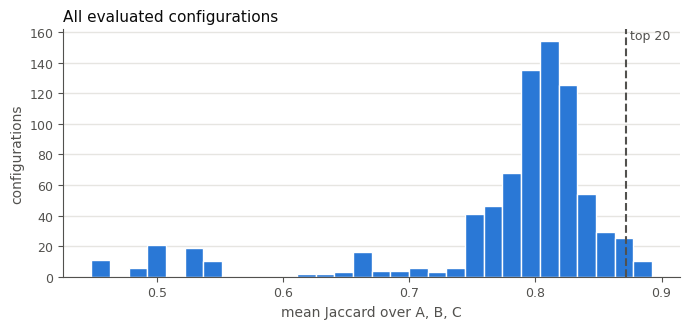

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.4), facecolor="white")
style_axes(ax)
ax.hist(summary["jaccard"], bins=30, color=BLUE, edgecolor="white", linewidth=1)
threshold = summary["jaccard"].sort_values(ascending=False).iloc[19]
ax.axvline(threshold, color=MUTED, linestyle="--", linewidth=1.5)
ax.text(threshold, ax.get_ylim()[1], " top 20", color=MUTED, va="top", fontsize=9)
ax.set_xlabel("mean Jaccard over A, B, C", color=MUTED)
ax.set_ylabel("configurations", color=MUTED)
ax.set_title("All evaluated configurations", loc="left", fontsize=11, color=INK)
fig.tight_layout()
plt.show()

## 3. The top 20

`top_configurations.csv` holds the 20 best configurations, with every metric the benchmark computed: for `jaccard`, `precision` and `recall` the mean over the texts and its distribution (median, std, quartiles q1 and q3, min, max), and the `exact_match` rate, averaged over the corpora A, B and C with equal weight. A row position here (0 to 19, rank 1 = row 0) is what `SELECTED` takes in `pegcomparison.ipynb`.

In [4]:
# The settings and the mean of every metric.
display(top[["rank", "variant", *SETTINGS, *METRICS]].round(4))

# The distribution of jaccard, precision and recall over the texts.
for metric in ("jaccard", "precision", "recall"):
    print(f"=== {metric} ===")
    display(top[["rank", "variant", metric, *[f"{metric}_{stat}" for stat in STAT_NAMES]]].round(4))

,rank,variant,theta_filter,min_size_frac,max_depth,h,relative_h,theta_stop,jaccard,precision,recall,exact_match
0,1,harmonic,0.3,0.02,4,0.20,True,0.1,0.8924,0.9521,0.9280,0.7402
1,2,harmonic,0.3,0.03,6,0.20,True,0.1,0.8924,0.9521,0.9280,0.7402
2,3,harmonic,0.3,0.02,6,0.20,True,0.1,0.8924,0.9521,0.9280,0.7402
3,4,harmonic,0.3,0.02,4,0.15,True,0.1,0.8875,0.9464,0.9371,0.7278
4,5,harmonic,0.3,0.03,4,0.15,True,0.1,0.8875,0.9464,0.9371,0.7278
5,6,harmonic,0.2,0.03,4,0.15,True,0.1,0.8845,0.9432,0.9373,0.7233
6,7,harmonic,0.4,0.03,4,0.20,True,0.1,0.8832,0.9476,0.9241,0.7102
7,8,harmonic,0.4,0.03,6,0.20,True,0.1,0.8832,0.9476,0.9241,0.7102
8,9,avg,0.3,0.02,6,0.10,True,0.1,0.8794,0.9449,0.9303,0.7096
9,10,avg,0.3,0.02,8,0.10,True,0.1,0.8794,0.9449,0.9303,0.7096


=== jaccard ===


,rank,variant,jaccard,jaccard_median,jaccard_std,jaccard_q1,jaccard_q3,jaccard_min,jaccard_max
0,1,harmonic,0.8924,1.0,0.2070,0.8333,1.0,0.1944,1.0
1,2,harmonic,0.8924,1.0,0.2070,0.8333,1.0,0.1944,1.0
2,3,harmonic,0.8924,1.0,0.2070,0.8333,1.0,0.1944,1.0
3,4,harmonic,0.8875,1.0,0.2064,0.8125,1.0,0.1944,1.0
4,5,harmonic,0.8875,1.0,0.2064,0.8125,1.0,0.1944,1.0
5,6,harmonic,0.8845,1.0,0.2097,0.8125,1.0,0.1944,1.0
6,7,harmonic,0.8832,1.0,0.2087,0.8333,1.0,0.1944,1.0
7,8,harmonic,0.8832,1.0,0.2087,0.8333,1.0,0.1944,1.0
8,9,avg,0.8794,1.0,0.2116,0.7500,1.0,0.1944,1.0
9,10,avg,0.8794,1.0,0.2116,0.7500,1.0,0.1944,1.0


=== precision ===


,rank,variant,precision,precision_median,precision_std,precision_q1,precision_q3,precision_min,precision_max
0,1,harmonic,0.9521,1.0,0.1269,1.0000,1.0,0.3333,1.0
1,2,harmonic,0.9521,1.0,0.1269,1.0000,1.0,0.3333,1.0
2,3,harmonic,0.9521,1.0,0.1269,1.0000,1.0,0.3333,1.0
3,4,harmonic,0.9464,1.0,0.1367,1.0000,1.0,0.2667,1.0
4,5,harmonic,0.9464,1.0,0.1367,1.0000,1.0,0.2667,1.0
5,6,harmonic,0.9432,1.0,0.1402,0.9167,1.0,0.2667,1.0
6,7,harmonic,0.9476,1.0,0.1272,0.9167,1.0,0.3333,1.0
7,8,harmonic,0.9476,1.0,0.1272,0.9167,1.0,0.3333,1.0
8,9,avg,0.9449,1.0,0.1452,1.0000,1.0,0.2667,1.0
9,10,avg,0.9449,1.0,0.1452,1.0000,1.0,0.2667,1.0


=== recall ===


,rank,variant,recall,recall_median,recall_std,recall_q1,recall_q3,recall_min,recall_max
0,1,harmonic,0.9280,1.0,0.1849,0.9167,1.0,0.1944,1.0
1,2,harmonic,0.9280,1.0,0.1849,0.9167,1.0,0.1944,1.0
2,3,harmonic,0.9280,1.0,0.1849,0.9167,1.0,0.1944,1.0
3,4,harmonic,0.9371,1.0,0.1601,0.9167,1.0,0.1944,1.0
4,5,harmonic,0.9371,1.0,0.1601,0.9167,1.0,0.1944,1.0
5,6,harmonic,0.9373,1.0,0.1593,0.9167,1.0,0.1944,1.0
6,7,harmonic,0.9241,1.0,0.1863,0.9167,1.0,0.1944,1.0
7,8,harmonic,0.9241,1.0,0.1863,0.9167,1.0,0.1944,1.0
8,9,avg,0.9303,1.0,0.1639,0.9167,1.0,0.1944,1.0
9,10,avg,0.9303,1.0,0.1639,0.9167,1.0,0.1944,1.0


### The top 20, per corpus

The same configurations on each corpus and overall. `benchmark_results.csv` has every configuration's metrics per corpus, `benchmark_configuration_summary.csv` the overall ones.

In [5]:
per_corpus = pd.concat([by_corpus, summary.assign(corpus="Overall")])
per_corpus = per_corpus[per_corpus["rank"].isin(top["rank"])].assign(row=lambda d: d["rank"] - 1)

top20_by_corpus = {}
for metric in METRICS:
    print(f"=== {metric}: top 20 configurations by corpus ===")
    top20_by_corpus[metric] = per_corpus.pivot(index=["row", "variant"], columns="corpus", values=metric)[[*CORPORA, "Overall"]]
    display(top20_by_corpus[metric].rename_axis(None, axis=1).round(3))

=== jaccard: top 20 configurations by corpus ===


,,A_default,B_weak_signal,C_deep,Overall
row,variant,,,,
0,harmonic,0.917,0.877,0.883,0.892
1,harmonic,0.917,0.877,0.883,0.892
2,harmonic,0.917,0.877,0.883,0.892
3,harmonic,0.899,0.879,0.885,0.888
4,harmonic,0.899,0.879,0.885,0.888
5,harmonic,0.899,0.870,0.885,0.884
6,harmonic,0.911,0.863,0.875,0.883
7,harmonic,0.911,0.863,0.875,0.883
8,avg,0.882,0.883,0.873,0.879


=== precision: top 20 configurations by corpus ===


,,A_default,B_weak_signal,C_deep,Overall
row,variant,,,,
0,harmonic,0.978,0.884,0.995,0.952
1,harmonic,0.978,0.884,0.995,0.952
2,harmonic,0.978,0.884,0.995,0.952
3,harmonic,0.957,0.888,0.993,0.946
4,harmonic,0.957,0.888,0.993,0.946
5,harmonic,0.957,0.879,0.993,0.943
6,harmonic,0.977,0.872,0.994,0.948
7,harmonic,0.977,0.872,0.994,0.948
8,avg,0.949,0.896,0.990,0.945


=== recall: top 20 configurations by corpus ===


,,A_default,B_weak_signal,C_deep,Overall
row,variant,,,,
0,harmonic,0.938,0.957,0.889,0.928
1,harmonic,0.938,0.957,0.889,0.928
2,harmonic,0.938,0.957,0.889,0.928
3,harmonic,0.941,0.978,0.891,0.937
4,harmonic,0.941,0.978,0.891,0.937
5,harmonic,0.941,0.979,0.891,0.937
6,harmonic,0.935,0.957,0.881,0.924
7,harmonic,0.935,0.957,0.881,0.924
8,avg,0.933,0.975,0.883,0.930


=== exact_match: top 20 configurations by corpus ===


,,A_default,B_weak_signal,C_deep,Overall
row,variant,,,,
0,harmonic,0.786,0.728,0.707,0.740
1,harmonic,0.786,0.728,0.707,0.740
2,harmonic,0.786,0.728,0.707,0.740
3,harmonic,0.750,0.716,0.717,0.728
4,harmonic,0.750,0.716,0.717,0.728
5,harmonic,0.750,0.702,0.717,0.723
6,harmonic,0.772,0.672,0.686,0.710
7,harmonic,0.772,0.672,0.686,0.710
8,avg,0.714,0.741,0.674,0.710


## 4. Which PEG formulations are in the top 20?

For every formulation: how many of the top 20 use it, its best rank, and how it did over **everything that was evaluated** with it.

The search sampled only a part of the grid, so each non-PEG setting was evaluated with only some of the formulations: this table says which configurations scored best in the sample, not which formulation is best at a fixed setting. That comparison is `pegcomparison.ipynb`.

In [6]:
formulations = summary.groupby("variant")["jaccard"].agg(
    n_configs_evaluated="count", best_jaccard="max", mean_jaccard="mean", median_jaccard="median",
)
formulations.insert(0, "best_rank", summary.groupby("variant")["rank"].min())
formulations.insert(0, "n_in_top20", summary[summary["rank"] <= 20]["variant"].value_counts())
formulations["n_in_top20"] = formulations["n_in_top20"].fillna(0).astype(int)
formulations = formulations.loc[list(PEG_VARIANTS)].reset_index().round(4)
display(formulations)

,variant,n_in_top20,best_rank,n_configs_evaluated,best_jaccard,mean_jaccard,median_jaccard
0,max,0,64,155,0.8503,0.7950,0.7991
1,avg,9,9,175,0.8794,0.7256,0.8037
2,min,0,142,167,0.8287,0.7905,0.7971
3,mean,0,78,142,0.8429,0.8041,0.8098
4,harmonic,11,1,161,0.8924,0.7727,0.8234


## 5. How much does each hyperparameter matter?

For every value of every hyperparameter: the number of configurations, the mean and the best mean Jaccard of the configurations that use it. Because the search is random, each value is combined with many different settings of the others, so the mean is a fair summary of how the value does on average; an interaction between two hyperparameters (see `relative_h` and `h` in the next section) is not visible here.

In [7]:
rows = []
for parameter in [*SETTINGS, "variant"]:
    grouped = summary.groupby(parameter)["jaccard"].agg(configurations="count", mean="mean", best="max")
    for value, values in grouped.iterrows():
        rows.append({"parameter": parameter, "value": value, **values})
effects = pd.DataFrame(rows)
effects["value"] = effects["value"].astype(str)
display(effects.set_index(["parameter", "value"]).round(3))

configurations   mean   best
parameter     value                                 
theta_filter  0.2                277.0  0.780  0.884
              0.3                258.0  0.780  0.892
              0.4                265.0  0.768  0.883
min_size_frac 0.02               265.0  0.777  0.892
              0.03               270.0  0.778  0.892
              0.05               265.0  0.773  0.875
max_depth     4                  270.0  0.783  0.892
              6                  254.0  0.771  0.892
              8                  276.0  0.774  0.879
h             0.05               199.0  0.803  0.868
              0.1                200.0  0.794  0.879
              0.15               196.0  0.777  0.888
              0.2                205.0  0.731  0.892
relative_h    False              406.0  0.744  0.854
              True               394.0  0.809  0.892
theta_stop    0.05               277.0  0.768  0.863
              0.1                263.0  0.788  0.892
              0.15               260.0  0.773  0.860
variant       avg                175.0  0.726  0.879
              harmonic           161.0  0.773  0.892
              max                155.0  0.795  0.850
              mean               142.0  0.804  0.843
              min                167.0  0.790  0.829

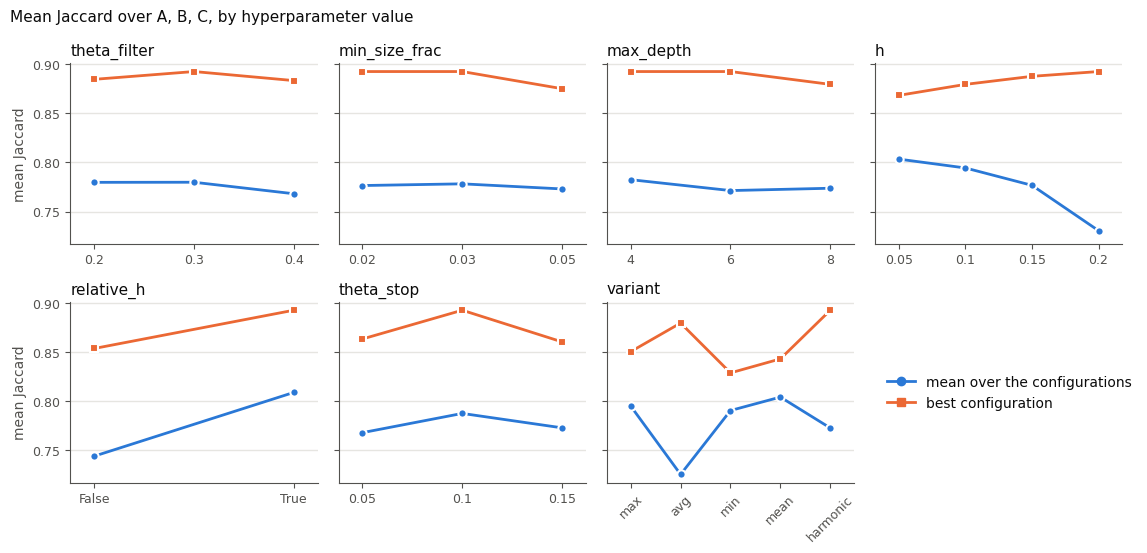

In [8]:
PARAMETERS = [*SETTINGS, "variant"]
fig, axes = plt.subplots(2, 4, figsize=(12, 5.6), sharey=True, facecolor="white")
for ax, parameter in zip(axes.flat, PARAMETERS):
    style_axes(ax)
    part = effects[effects["parameter"] == parameter]
    if parameter == "variant":
        part = part.set_index("value").loc[list(PEG_VARIANTS)].reset_index()
    ax.plot(part["value"], part["best"], color=ORANGE, marker="s", linewidth=2, markersize=6,
            markeredgecolor="white", markeredgewidth=1.5)
    ax.plot(part["value"], part["mean"], color=BLUE, marker="o", linewidth=2, markersize=6,
            markeredgecolor="white", markeredgewidth=1.5)
    ax.set_title(parameter, loc="left", fontsize=11, color=INK)
    ax.margins(x=0.12)
    if parameter == "variant":
        ax.tick_params(axis="x", labelrotation=45)
for ax in axes[:, 0]:
    ax.set_ylabel("mean Jaccard", color=MUTED)

legend_ax = axes.flat[-1]                   # the eighth panel carries the legend
legend_ax.axis("off")
legend_ax.plot([], [], color=BLUE, marker="o", linewidth=2, markersize=6, label="mean over the configurations")
legend_ax.plot([], [], color=ORANGE, marker="s", linewidth=2, markersize=6, label="best configuration")
legend_ax.legend(loc="center left", frameon=False, labelcolor=INK)

fig.suptitle("Mean Jaccard over A, B, C, by hyperparameter value", x=0.01, ha="left", fontsize=11, color=INK)
fig.tight_layout()
plt.show()

## 6. `relative_h`: does it matter?

`h` is the minimum gain a split must have to be made. With `relative_h=False` the best PEG must exceed `h`; with `relative_h=True` the best PEG **divided by the node's nDFU** must exceed `h`. The two modes put `h` on different scales, so **the same `h` does not mean the same thing** and they can't be compared at a single value.

First, what the search already says: the mean Jaccard of the sampled configurations by mode and `h`.

In [9]:
display(summary.pivot_table(index="relative_h", columns="h", values="jaccard", aggfunc="mean").round(3))
print("configurations:")
display(summary.pivot_table(index="relative_h", columns="h", values="jaccard", aggfunc="count"))

h,0.05,0.10,0.15,0.20
relative_h,,,,
False,0.802,0.779,0.74,0.655
True,0.805,0.812,0.81,0.809


configurations:


h,0.05,0.10,0.15,0.20
relative_h,,,,
False,103,105,94,104
True,96,95,102,101


### A controlled experiment

The sample is confounded: everything else varies at random, and the best settings of one mode need not suit the other. So hold everything fixed except `relative_h` and `h`, and run the benchmark's full grid: `relative_h` × `variant` × `h` on the three corpora, with the metrics computed per corpus and averaged with equal weight.

The other settings (`theta_filter`, `min_size_frac`, `max_depth`, `theta_stop`) come from the best configuration of the search with the given `relative_h`. Those settings were chosen together with the mode of that configuration, which can favour it: run this section once with `BASE_FROM_RELATIVE_H = True` and once with `False` to see whether the conclusion depends on it.

In [10]:
BASE_FROM_RELATIVE_H = True
H_GRID = [0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
N_JOBS = 4          # worker processes; each holds its own copy of the data (~150 MB)

candidates = summary[summary["relative_h"] == BASE_FROM_RELATIVE_H]
base_row = candidates.loc[candidates["jaccard"].idxmax()]
BASE = {key: base_row[key].item() for key in ["theta_filter", "min_size_frac", "max_depth", "theta_stop"]}

print(f"Other settings, from the best configuration with relative_h={BASE_FROM_RELATIVE_H} "
      f"(rank {base_row['rank']}, h={base_row['h']}, {base_row['variant']}, mean Jaccard {base_row['jaccard']:.3f}):")
print(BASE)

dataset, ground_truth, text_groups = load_benchmark_dataset()

grid = PolarizedTreesBenchmark(
    pipeline=PolarizedTreesPipeline(dims=DIMS, scale=SCALE, h=0.1, **{k: BASE[k] for k in ("theta_filter", "max_depth")}),
    annotations=dataset,
    ground_truth=ground_truth,
    text_groups=text_groups,
    search_space={
        **{key: [value] for key, value in BASE.items()},
        "variant": list(PEG_VARIANTS),
        "relative_h": [False, True],
        "h": H_GRID,
    },
    strategy="full",
    n_jobs=N_JOBS,
    verbose=False,
).run()

grid_overall = grid.get_results()            # one row per configuration: the metrics averaged over A, B, C
grid_by_corpus = grid.get_group_results()    # one row per configuration and corpus
print(f"\n{len(grid_overall)} configurations")

Other settings, from the best configuration with relative_h=True (rank 1, h=0.2, harmonic, mean Jaccard 0.892):
{'theta_filter': 0.3, 'min_size_frac': 0.02, 'max_depth': 4, 'theta_stop': 0.1}

80 configurations


Mean Jaccard against `h`: one panel per PEG formulation, one line per mode, over A, B and C; the panels share the y-axis.

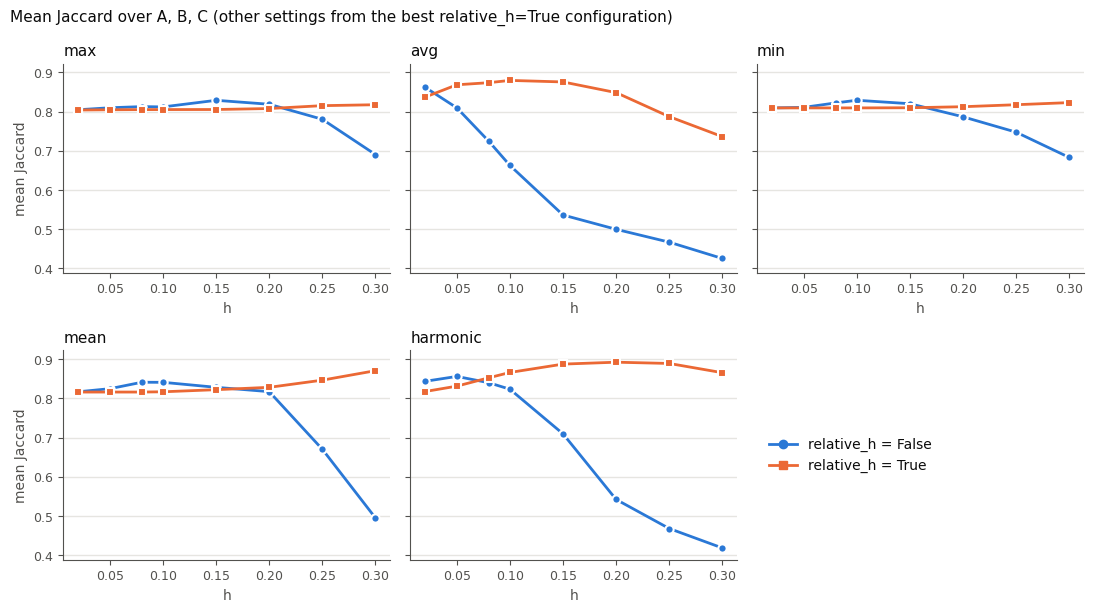

In [11]:
MODES = {
    False: dict(color=BLUE, marker="o", label="relative_h = False"),
    True: dict(color=ORANGE, marker="s", label="relative_h = True"),
}
low, high = grid_overall["jaccard"].min(), grid_overall["jaccard"].max()

fig, axes = plt.subplots(2, 3, figsize=(11, 6.2), sharey=True, facecolor="white")
for ax, variant in zip(axes.flat, PEG_VARIANTS):
    style_axes(ax)
    for mode, style in MODES.items():
        rows = grid_overall[(grid_overall["variant"] == variant) & (grid_overall["relative_h"] == mode)].sort_values("h")
        ax.plot(rows["h"], rows["jaccard"], color=style["color"], marker=style["marker"],
                linewidth=2, markersize=6, markeredgecolor="white", markeredgewidth=1.5)
    ax.set_title(variant, loc="left", fontsize=11, color=INK)
    ax.set_xlabel("h", color=MUTED)
    ax.set_ylim(low - 0.03, high + 0.03)
for ax in axes[:, 0]:
    ax.set_ylabel("mean Jaccard", color=MUTED)

legend_ax = axes.flat[-1]                   # the sixth panel carries the legend
legend_ax.axis("off")
for mode, style in MODES.items():
    legend_ax.plot([], [], color=style["color"], marker=style["marker"], linewidth=2, markersize=6, label=style["label"])
legend_ax.legend(loc="center left", frameon=False, labelcolor=INK)

fig.suptitle(f"Mean Jaccard over A, B, C (other settings from the best relative_h={BASE_FROM_RELATIVE_H} configuration)",
             x=0.01, ha="left", fontsize=11, color=INK)
fig.tight_layout()
plt.show()

Each mode at its best `h`: for every formulation and mode, the `h` with the highest overall mean Jaccard, and the Jaccard of that configuration on A, B, C and overall. *Gain* is `relative_h=True` minus `relative_h=False`.

In [12]:
best_h = grid_overall.loc[grid_overall.groupby(["variant", "relative_h"])["jaccard"].idxmax(), ["variant", "relative_h", "h"]]
best_h = best_h.merge(grid_by_corpus[["variant", "relative_h", "h", "corpus", "jaccard"]], on=["variant", "relative_h", "h"])
best_h = best_h.pivot(index=["variant", "relative_h", "h"], columns="corpus", values="jaccard")
best_h["Overall"] = grid_overall.set_index(["variant", "relative_h", "h"]).loc[best_h.index, "jaccard"]

best_h = best_h.reset_index().set_index("variant").loc[list(PEG_VARIANTS)].reset_index()
display(best_h.rename_axis(None, axis=1).round(3))

wide = best_h.pivot(index="variant", columns="relative_h", values="Overall").loc[list(PEG_VARIANTS)]
gain = (wide[True] - wide[False]).rename("Gain (True - False)")
display(pd.concat([wide.rename(columns=lambda mode: f"relative_h = {mode}"), gain], axis=1).round(3))

,variant,relative_h,h,A_default,B_weak_signal,C_deep,Overall
0,max,False,0.15,0.818,0.841,0.827,0.829
1,max,True,0.30,0.810,0.806,0.836,0.817
2,avg,False,0.02,0.848,0.891,0.848,0.862
3,avg,True,0.10,0.882,0.883,0.873,0.879
4,min,False,0.10,0.793,0.870,0.823,0.829
5,min,True,0.30,0.801,0.848,0.819,0.823
6,mean,False,0.08,0.796,0.882,0.846,0.841
7,mean,True,0.30,0.866,0.889,0.857,0.871
8,harmonic,False,0.05,0.837,0.883,0.848,0.856
9,harmonic,True,0.20,0.917,0.877,0.883,0.892


,relative_h = False,relative_h = True,Gain (True - False)
variant,,,
max,0.829,0.817,-0.011
avg,0.862,0.879,0.017
min,0.829,0.823,-0.006
mean,0.841,0.871,0.029
harmonic,0.856,0.892,0.036


What `h` does to the trees: leaves and depth against `h` for one formulation (`SIZE_VARIANT`), averaged over A, B and C. A larger `h` stops splitting earlier. The benchmark only reports recovery, so these come from the pipeline's diagnostics.

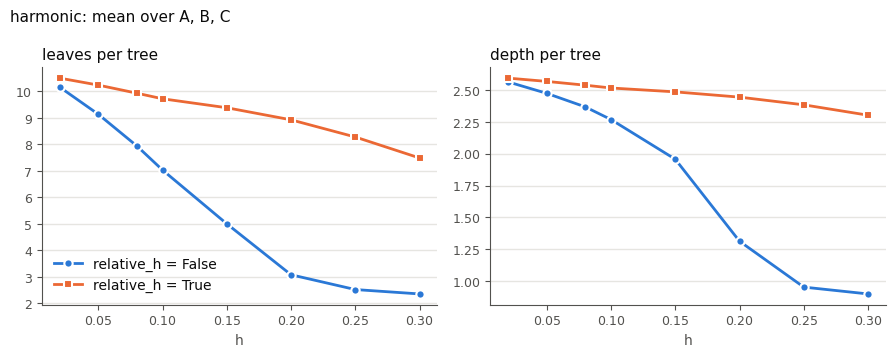

In [13]:
SIZE_VARIANT = "harmonic"
corpora = load_benchmark_corpora()

rows = []
for mode in (False, True):
    for h in H_GRID:
        for corpus, (data, truth) in corpora.items():
            pipe = PolarizedTreesPipeline(dims=DIMS, scale=SCALE, variant=SIZE_VARIANT, relative_h=mode, h=h, **BASE)
            diagnostics = pipe.run_full_evaluation(data, ground_truth=truth, verbose=False)["diagnostics"]
            rows.append({"relative_h": mode, "h": h, "corpus": corpus,
                         "mean_leaves": diagnostics["mean_leaves"], "mean_depth": diagnostics["mean_depth"]})
tree_size = pd.DataFrame(rows).groupby(["relative_h", "h"], as_index=False)[["mean_leaves", "mean_depth"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), facecolor="white")
for ax, column, name in zip(axes, ("mean_leaves", "mean_depth"), ("leaves per tree", "depth per tree")):
    style_axes(ax)
    for mode, style in MODES.items():
        part = tree_size[tree_size["relative_h"] == mode]
        ax.plot(part["h"], part[column], color=style["color"], marker=style["marker"], linewidth=2,
                markersize=6, markeredgecolor="white", markeredgewidth=1.5, label=style["label"])
    ax.set_title(name, loc="left", fontsize=11, color=INK)
    ax.set_xlabel("h", color=MUTED)
axes[0].legend(frameon=False, labelcolor=INK)
fig.suptitle(f"{SIZE_VARIANT}: mean over A, B, C", x=0.01, ha="left", fontsize=11, color=INK)
fig.tight_layout()
plt.show()

## 7. Do the same settings work on A, B and C?

The corpora are three regimes: A (default), B (weak signal) and C (deep intersectional). Three questions: how hard is each, do the configurations that are good on one corpus also do well on the others, and does the best configuration differ?

In [14]:
wide_corpora = by_corpus.pivot(index="configuration_id", columns="corpus", values="jaccard")[CORPORA]

print("Jaccard of the evaluated configurations, per corpus:")
display(wide_corpora.describe().loc[["mean", "min", "50%", "max"]].rename(index={"50%": "median"}).round(3))

print("Correlation between the corpora, over the configurations:")
display(wide_corpora.corr().round(3))

print("The best configuration of each corpus:")
best_per_corpus = by_corpus.loc[by_corpus.groupby("corpus")["jaccard"].idxmax(), ["corpus", "rank", "variant", *SETTINGS, "jaccard"]]
display(best_per_corpus.set_index("corpus").round(3))

Jaccard of the evaluated configurations, per corpus:


corpus,A_default,B_weak_signal,C_deep
mean,0.770,0.789,0.769
min,0.512,0.424,0.409
median,0.779,0.834,0.800
max,0.917,0.906,0.920


Correlation between the corpora, over the configurations:


corpus,A_default,B_weak_signal,C_deep
corpus,,,
A_default,1.000,0.795,0.864
B_weak_signal,0.795,1.000,0.694
C_deep,0.864,0.694,1.000


The best configuration of each corpus:


,rank,variant,theta_filter,min_size_frac,max_depth,h,relative_h,theta_stop,jaccard
corpus,,,,,,,,,
A_default,1,harmonic,0.3,0.02,4,0.20,True,0.10,0.917
B_weak_signal,13,avg,0.3,0.03,8,0.15,True,0.10,0.906
C_deep,50,avg,0.4,0.03,4,0.10,True,0.05,0.920


## 8. Recovery by the true number of active dimensions (k)

A text has between one and four truly active dimensions. For the best configuration of every formulation: mean recovery by k, over the texts of A, B and C that were analysed (a text is analysed when its nDFU reaches `theta_filter`, so the numbers of texts differ between configurations). *Precision* low means extra dimensions were added (over-splitting), *recall* low means true dimensions were missed (under-splitting).

In [15]:
text_results = pd.read_csv(RESULTS_DIR / "benchmark_text_results.csv",
                           usecols=["configuration_id", "corpus", "text_id", "k_true", *METRICS])

best_of_formulation = summary.loc[summary.groupby("variant")["jaccard"].idxmax(), ["variant", "configuration_id"]]
texts = text_results.merge(best_of_formulation, on="configuration_id")
texts[METRICS] = texts[METRICS].astype(float)

grouped = texts.groupby(["variant", "k_true"])
recovery_by_k = grouped[METRICS].mean()
recovery_by_k.insert(0, "texts", grouped.size())

print("texts per k:")
display(recovery_by_k["texts"].unstack("k_true").loc[list(PEG_VARIANTS)])
for metric in METRICS:
    print(f"=== mean {metric} by k (the best configuration of each formulation) ===")
    display(recovery_by_k[metric].unstack("k_true").loc[list(PEG_VARIANTS)].round(3))

texts per k:


k_true,1,2,3,4
variant,,,,
max,64,66,64,66
avg,62,65,64,66
min,62,65,64,66
mean,62,65,64,66
harmonic,62,65,64,66


=== mean jaccard by k (the best configuration of each formulation) ===


k_true,1,2,3,4
variant,,,,
max,0.964,0.727,0.868,0.847
avg,0.977,0.750,0.935,0.860
min,0.989,0.568,0.954,0.811
mean,0.987,0.565,0.954,0.871
harmonic,0.989,0.798,0.927,0.860


=== mean precision by k (the best configuration of each formulation) ===


k_true,1,2,3,4
variant,,,,
max,0.964,0.848,0.910,0.984
avg,0.977,0.835,0.977,1.000
min,0.989,0.675,0.996,1.000
mean,0.987,0.711,0.996,1.000
harmonic,0.989,0.875,0.969,0.985


=== mean recall by k (the best configuration of each formulation) ===


k_true,1,2,3,4
variant,,,,
max,0.984,0.848,0.911,0.856
avg,1.000,0.915,0.943,0.860
min,1.000,0.892,0.958,0.811
mean,1.000,0.854,0.958,0.871
harmonic,1.000,0.908,0.943,0.860


=== mean exact_match by k (the best configuration of each formulation) ===


k_true,1,2,3,4
variant,,,,
max,0.953,0.394,0.688,0.530
avg,0.968,0.462,0.891,0.530
min,0.984,0.077,0.922,0.333
mean,0.984,0.092,0.922,0.576
harmonic,0.984,0.554,0.859,0.576


## 9. Save

In [16]:
formulations.to_csv(OUT_DIR / "top20_formulations.csv", index=False)
effects.to_csv(OUT_DIR / "hyperparameter_effects.csv", index=False)
best_per_corpus.to_csv(OUT_DIR / "best_per_corpus.csv", index=False)
recovery_by_k.to_csv(OUT_DIR / "recovery_by_k.csv")
for metric, table in top20_by_corpus.items():
    table.to_csv(OUT_DIR / f"top20_by_corpus_{metric}.csv")

suffix = f"base_relative_h_{BASE_FROM_RELATIVE_H}"
grid_overall.to_csv(OUT_DIR / f"relative_h_grid_{suffix}.csv", index=False)
grid_by_corpus.to_csv(OUT_DIR / f"relative_h_grid_by_corpus_{suffix}.csv", index=False)
best_h.to_csv(OUT_DIR / f"relative_h_best_h_{suffix}.csv", index=False)
tree_size.to_csv(OUT_DIR / f"relative_h_tree_size_{suffix}.csv", index=False)

print("Saved to:", OUT_DIR.resolve())

Saved to: C:\Users\swkra\OneDrive\Υπολογιστής\ερευνα\HumanModelAlign\polarizedtrees\benchmarks\benchmark_results\exploration
